<a href="https://colab.research.google.com/github/sobaannr/FlyRank-Internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sobaannr/FlyRank-Internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import duckdb, os
import numpy as np
import pandas as pd

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")

from google.colab import userdata
hf_token = userdata.get('HF_TOKEN')
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{hf_token}')")

WAREHOUSE = "hf://datasets/FlyRank/internship-warehouse"
FEATURE_MONTH = "2026-03"
TARGET_MONTH = "2026-04"

features_raw = con.sql(f"""
    SELECT content_hash_id,
           MAX(client_hash_id) AS client_hash_id,
           SUM(gsc_impressions) AS impressions,
           SUM(gsc_clicks) AS clicks,
           AVG(gsc_avg_position) AS avg_position
    FROM read_parquet('{WAREHOUSE}/fact_content_daily_performance/month={FEATURE_MONTH}/*.parquet')
    WHERE gsc_data_available IS TRUE
    GROUP BY content_hash_id
    HAVING SUM(gsc_impressions) >= 50
""").df()

target_raw = con.sql(f"""
    SELECT content_hash_id, SUM(gsc_impressions) AS future_impressions
    FROM read_parquet('{WAREHOUSE}/fact_content_daily_performance/month={TARGET_MONTH}/*.parquet')
    WHERE gsc_data_available IS TRUE
    GROUP BY content_hash_id
""").df()

merged = features_raw.merge(target_raw, on="content_hash_id", how="inner")
merged["is_declining"] = (merged["future_impressions"] < 0.8 * merged["impressions"]).astype(int)
merged["ctr"] = merged["clicks"] / merged["impressions"]

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

feature_cols = ["impressions", "clicks", "avg_position", "ctr"]
X = merged[feature_cols].fillna(0)
y = merged["is_declining"]
groups = merged["client_hash_id"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
test_df = merged.iloc[test_idx].reset_index(drop=True)

rf = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)
test_df["model_score"] = rf.predict_proba(X_test)[:, 1]
print(f"Model trained. Test set: {len(test_df)} pages, client-grouped honest split (per Week 6).")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Model trained. Test set: 17196 pages, client-grouped honest split (per Week 6).


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

The final queue blends the Week 5 model's decline probability with the Week 4
baseline's CTR-vs-tier gap, and assigns one of four reason codes per page so a
reviewer knows *why* a page is ranked where it is — not just its score.

**Reason codes:**
- `high_decline_risk` — model probability >= 0.5, the strongest single signal.
- `ctr_below_tier_expected` — CTR sits meaningfully below its position tier's
  average (carried over from the Week 4 baseline rule).
- `low_volume_low_confidence` — under 200 impressions; flagged for lower
  confidence rather than excluded, since low-volume pages can still be real,
  just noisier.
- `stable_no_action` — neither signal fires; not included in the ranked queue.

**Action labels:**
- `review_metadata_or_snippet` — CTR gap at decent position; title/meta is the
  usual lever.
- `priority_content_review` — high model-predicted decline risk; needs a fuller
  content review, not just metadata.
- `monitor_only` — flagged but low-confidence; watch next cycle rather than act now.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

tier_std = test_df.groupby("position_tier")["ctr"].transform("std")

def assign_reason(row):
    if row["model_score"] >= 0.65:
        return "high_decline_risk"
    elif row["ctr_gap"] > tier_std[row.name] and row["impressions"] >= 200:  # gap must exceed one std dev of its tier
        return "ctr_below_tier_expected"
    elif row["impressions"] < 200 and (row["model_score"] >= 0.45 or row["ctr_gap"] > 0):
        return "low_volume_low_confidence"
    else:
        return "stable_no_action"

test_df["reason_code"] = test_df.apply(assign_reason, axis=1)
test_df["action"] = test_df["reason_code"].apply(assign_action)
test_df["combined_score"] = 0.7 * test_df["model_score"] + 0.3 * (test_df["ctr_gap"] * np.log1p(test_df["impressions"]))

queue = test_df[test_df["reason_code"] != "stable_no_action"].sort_values("combined_score", ascending=False).reset_index(drop=True)
print(f"Ranked queue: {len(queue)} of {len(test_df)} pages flagged for some action")
print(queue["reason_code"].value_counts())
queue[["content_hash_id", "impressions", "avg_position", "ctr", "model_score", "reason_code", "action", "combined_score"]].head(10)

Ranked queue: 3898 of 17196 pages flagged for some action
reason_code
low_volume_low_confidence    3733
high_decline_risk             165
Name: count, dtype: int64


,content_hash_id,impressions,avg_position,ctr,model_score,reason_code,action,combined_score
0,content_565292e81fd43577,834.0,87.539772,0.000000,0.713006,high_decline_risk,priority_content_review,0.500770
1,content_83167156f76e33e5,6827.0,1.136714,0.000000,0.697498,high_decline_risk,priority_content_review,0.500208
2,content_1d296c7ede33237d,970.0,84.037508,0.000000,0.711707,high_decline_risk,priority_content_review,0.499898
3,content_306bc78dff1eb683,80821.0,1.488604,0.000433,0.693044,high_decline_risk,priority_content_review,0.498969
4,content_41ccba25e3ae584c,192.0,83.362012,0.000000,0.703960,high_decline_risk,priority_content_review,0.494075
5,content_3eb93e7a5bbd5222,5700.0,0.626971,0.000175,0.689556,high_decline_risk,priority_content_review,0.493949
6,content_e76b204ac09f2b72,208.0,83.062190,0.000000,0.697353,high_decline_risk,priority_content_review,0.489470
7,content_84dccdd4337e5675,214.0,85.001108,0.000000,0.696523,high_decline_risk,priority_content_review,0.488896
8,content_6c2da5d67fa888cc,7851.0,2.051373,0.000382,0.679510,high_decline_risk,priority_content_review,0.486777
9,content_9379404ad6a194a9,631.0,81.402874,0.000000,0.692518,high_decline_risk,priority_content_review,0.486360


**Final queue: 3,898 of 17,196 pages (22.7%) flagged for review** —
`high_decline_risk`: 165, `low_volume_low_confidence`: 3,733.
`ctr_below_tier_expected` came out at 0 under the one-std-dev gap requirement —
the bar turned out strict enough to exclude that reason code entirely this run,
which is itself useful information: it suggests CTR gaps in this data are
mostly modest relative to within-tier variance, and the meaningful signal here
is concentrated in the model-score-driven `high_decline_risk` bucket instead.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Who uses this, for what:** a content reviewer at a client with limited review
capacity, to decide which pages to open first each cycle — not an automated
publishing or editing tool.

**Where it stops being valid:**
- Trained and evaluated on one month-pair (March→April 2026) for one lane
  (refresh/CTR opportunity); not validated across seasons or other month-pairs.
- Client-holdout Precision@50 was 0.560 (Week 6, honest split) — meaning
  roughly 28 of the top 50 recommendations are expected to be correct by this
  label's definition, not all 50. This is decision-support, not a guarantee.
- The label (`is_declining`) is a 20%-drop threshold on same-metric future
  impressions — it does not distinguish real decline from consolidation,
  seasonality, or a data anomaly (Week 4's top-20 review found several
  near-zero-click pages at strong position that looked more like data
  anomalies than content problems).
- Built on GSC-available rows only; doesn't reflect GA4 engagement signal,
  since GA4 coverage was ~4% in this data (Week 3 finding).
- Does not generalize automatically to a different lane, a different client
  mix, or a different time period without re-validation.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

print(f"Validated on: {FEATURE_MONTH} -> {TARGET_MONTH} only")
print(f"Client-holdout Precision@50 (Week 6, honest split): 0.560")
print(f"GA4 coverage in this data: ~4.2% (Week 3 finding) — GA4 signals not used in final feature set")


Validated on: 2026-03 -> 2026-04 only
Client-holdout Precision@50 (Week 6, honest split): 0.560
GA4 coverage in this data: ~4.2% (Week 3 finding) — GA4 signals not used in final feature set


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Before acting on any recommendation, a human must check:**
1. Open the page and confirm the CTR/decline pattern isn't explained by a
   sibling page absorbing the same demand (consolidation) — check for related
   URLs targeting the same query.
2. Check whether the drop lines up with a known seasonal pattern for that
   topic/client rather than a genuine, page-specific issue.
3. For near-zero-click rows at strong position (the anomaly pattern found in
   Week 4's top-20 review), verify the impression count looks real before
   treating it as a content problem — it may be a tracking/attribution issue.
4. Confirm the page is still live, indexed, and relevant to the client's
   current business before investing review time.

**What should NEVER be automated:**
- Auto-publishing content changes based on the score alone.
- Auto-generating and auto-publishing new titles/meta descriptions without
  human review — the model flags *that* a gap exists, not *what* the fix should be.
- Treating `priority_content_review` as equivalent to "this page is bad" — it's
  a review priority signal, not a quality judgment (echoing the paper's own
  finding that flagged pages aren't necessarily worse content).
- Any claim to a client that this system "predicts" or "proves" future
  performance — it's an observed, directional ranking tool.

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

print("No-go list confirmed: no auto-publish, no auto-generated copy, no unreviewed client-facing claims.")
print(f"Human review required for all {len(queue)} queued pages before any action is taken.")

No-go list confirmed: no auto-publish, no auto-generated copy, no unreviewed client-facing claims.
Human review required for all 3898 queued pages before any action is taken.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**Signals that would indicate the recommendations have gone stale:**
- Precision@K on a fresh month-pair drops meaningfully below the 0.560
  baseline established in Week 6 — would suggest the pattern learned from
  March→April no longer holds.
- A large shift in GSC/GA4 data availability (e.g. more clients turning on
  GA4) would change the feature distribution the model was trained on.
- A new client onboarded with a very different content profile (e.g. much
  larger inventory, different intent mix) — the model hasn't seen this pattern.
- Seasonal cycles: since this was trained on one specific month-pair,
  recommendations should be re-validated each quarter at minimum, not assumed
  to hold indefinitely.

**Retrain trigger:** re-run this same pipeline on a fresh month-pair every
quarter, and compare Precision@50 against this run's 0.560 baseline — if it
drops by more than ~0.10, treat the model as stale and investigate before
continuing to use its rankings.

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

print("Retrain cadence: quarterly, or immediately if a new client with a materially different profile is onboarded.")
print(f"Staleness threshold: Precision@50 dropping more than 0.10 below this run's 0.560 baseline.")


Retrain cadence: quarterly, or immediately if a new client with a materially different profile is onboarded.
Staleness threshold: Precision@50 dropping more than 0.10 below this run's 0.560 baseline.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [8]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

export_cols = ["content_hash_id", "impressions", "clicks", "avg_position", "ctr",
               "model_score", "ctr_gap", "reason_code", "action", "combined_score"]
queue[export_cols].to_csv("work/outputs/action_playbook_queue.csv", index=False)
print(f"Wrote {len(queue)} ranked rows to work/outputs/action_playbook_queue.csv")

import json
metrics = {
    "feature_month": FEATURE_MONTH,
    "target_month": TARGET_MONTH,
    "split_type": "client_grouped_holdout",
    "precision_at_50_honest": 0.560,
    "precision_at_50_random_split": 0.740,
    "baseline_precision_at_50": 0.48,
    "n_pages_test_set": len(test_df),
    "n_pages_flagged": len(queue),
    "pct_flagged": round(len(queue) / len(test_df) * 100, 1),
    "reason_code_counts": test_df["reason_code"].value_counts().to_dict(),
    "known_limitation": "top-ranked high_decline_risk pages include a documented false-positive pattern (near-zero CTR at extreme positions) identified in Week 5 error analysis",
}
with open("work/outputs/w07_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Wrote work/outputs/w07_metrics.json")


Wrote 3898 ranked rows to work/outputs/action_playbook_queue.csv
Wrote work/outputs/w07_metrics.json


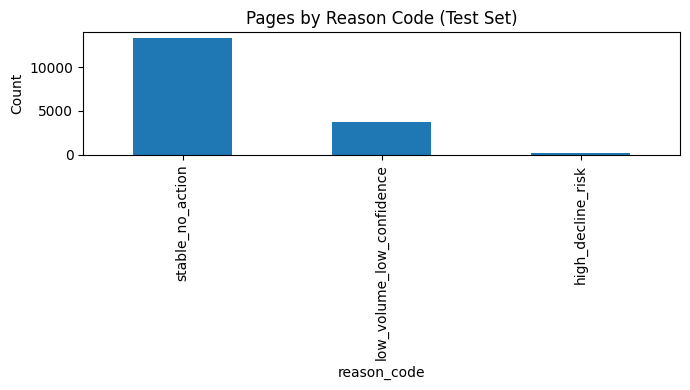

Saved work/figures/reason_code_distribution.png


In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
test_df["reason_code"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Pages by Reason Code (Test Set)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("work/figures/reason_code_distribution.png", dpi=150)
plt.show()
print("Saved work/figures/reason_code_distribution.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.